# EDA — surface inputs vs subsurface targets (2019 Q1)

Goal: understand shapes, land/NaN mask, map alignment, and how SST relates to `thetao` at depth before training.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Notebook lives in ml/configs/
ROOT = Path("../..").resolve()
DATA = ROOT / "data" / "processed" / "train_daily_JFM_2015_2024"
OUT = ROOT / "outputs" / "eda"
OUT.mkdir(parents=True, exist_ok=True)

surface = xr.open_dataset(DATA / "surface.nc", engine="h5netcdf")
target = xr.open_dataset(DATA / "target.nc", engine="h5netcdf")

CHANNELS = ["sst", "sss", "sla", "adt", "uo", "vo", "u10", "v10"]
DAY = 0  # 2019-01-01

print("ROOT:", ROOT)
print("surface:", dict(surface.sizes), list(surface.data_vars))
print("target: ", dict(target.sizes), list(target.data_vars))
print("time:   ", str(surface.time.values[0])[:10], "→", str(surface.time.values[-1])[:10])
print("depths: ", target.depth.values.tolist())


ROOT: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_26066
surface: {'time': 90, 'latitude': 100, 'longitude': 240} ['sst', 'sss', 'sla', 'adt', 'uo', 'vo', 'u10', 'v10']
target:  {'time': 90, 'depth': 15, 'latitude': 100, 'longitude': 240} ['thetao']
time:    2019-01-01 → 2019-03-31
depths:  [0.0, 5.0, 10.0, 20.0, 30.0, 50.0, 75.0, 100.0, 125.0, 150.0, 200.0, 300.0, 500.0, 700.0, 1000.0]


## 1. Grid alignment

X and Y must share the same `time`, `latitude`, `longitude` so each pixel is a paired sample.

In [5]:
assert np.array_equal(surface.time.values, target.time.values), "time mismatch"
assert np.allclose(surface.latitude, target.latitude), "lat mismatch"
assert np.allclose(surface.longitude, target.longitude), "lon mismatch"

print("time / lat / lon: aligned")
print(f"grid: {surface.sizes['latitude']} lat × {surface.sizes['longitude']} lon")
print(f"lat range: {float(surface.latitude.min()):.3f} → {float(surface.latitude.max()):.3f}")
print(f"lon range: {float(surface.longitude.min()):.3f} → {float(surface.longitude.max()):.3f}")

time / lat / lon: aligned
grid: 100 lat × 240 lon
lat range: 5.125 → 29.875
lon range: 45.125 → 104.875


## 2. Missing data & ocean mask

~half the grid is land or missing. Training loss must use only pixels where **both** surface and target are finite.

In [6]:
rows = []
for name in CHANNELS:
    a = surface[name].values
    rows.append((name, float(np.isnan(a).mean() * 100), int(np.isfinite(a).sum())))

th = target.thetao.values
rows.append(("thetao (all depths)", float(np.isnan(th).mean() * 100), int(np.isfinite(th).sum())))

print(f"{'var':22s}  {'% NaN':>8s}  {'finite':>12s}")
for name, pct, n in rows:
    print(f"{name:22s}  {pct:7.2f}%  {n:12d}")

print("\nthetao % NaN by depth:")
for d in target.depth.values:
    layer = target.thetao.sel(depth=d).values
    print(f"  {float(d):6.0f} m  {np.isnan(layer).mean()*100:6.2f}%")

var                        % NaN        finite
sst                       50.57%       1067670
sss                       52.05%       1035630
sla                       50.69%       1065150
adt                       50.79%       1062900
uo                        52.22%       1032120
vo                        52.22%       1032120
u10                       50.57%       1067670
v10                       50.57%       1067670
thetao (all depths)       57.89%      13644450

thetao % NaN by depth:
       0 m   51.22%
       5 m   51.22%
      10 m   52.62%
      20 m   53.91%
      30 m   55.26%
      50 m   57.14%
      75 m   58.90%
     100 m   59.83%
     125 m   60.06%
     150 m   60.23%
     200 m   60.62%
     300 m   60.93%
     500 m   61.59%
     700 m   62.20%
    1000 m   62.57%


day 2019-01-01
  SST finite:           11863
  thetao@0m finite:     11707
  both (train mask):    11707
  SST only (drop):        156
  target only:              0


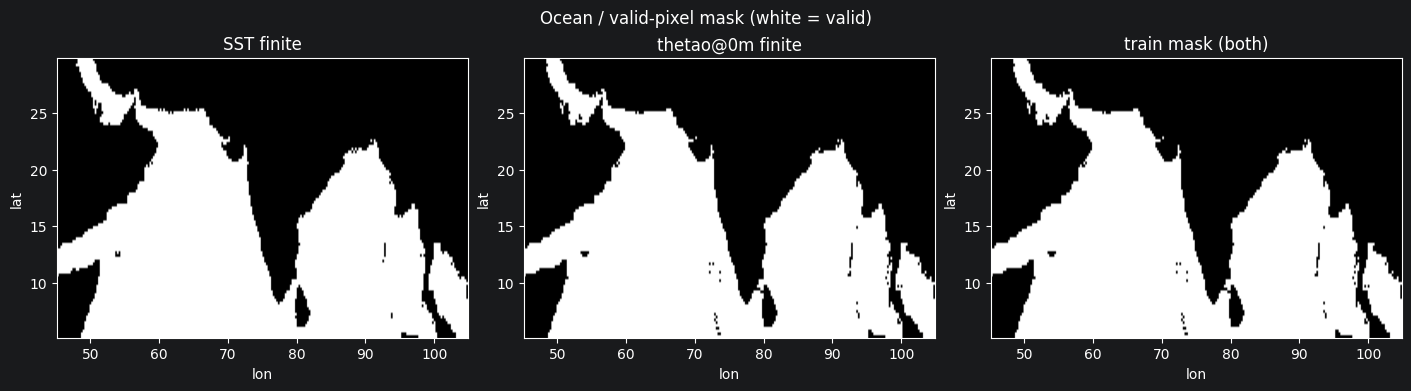

In [7]:
sst0 = surface.sst.isel(time=DAY)
th0 = target.thetao.isel(time=DAY, depth=0)

sst_ok = np.isfinite(sst0)
th_ok = np.isfinite(th0)
both = sst_ok & th_ok
sst_only = sst_ok & ~th_ok
th_only = ~sst_ok & th_ok

print(f"day {str(surface.time.values[DAY])[:10]}")
print(f"  SST finite:          {int(sst_ok.sum()):6d}")
print(f"  thetao@0m finite:    {int(th_ok.sum()):6d}")
print(f"  both (train mask):   {int(both.sum()):6d}")
print(f"  SST only (drop):     {int(sst_only.sum()):6d}")
print(f"  target only:         {int(th_only.sum()):6d}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
for ax, field, title in zip(
    axes,
    [sst_ok, th_ok, both],
    ["SST finite", "thetao@0m finite", "train mask (both)"],
):
    ax.imshow(
        field.values,
        origin="lower",
        extent=[
            float(surface.longitude.min()),
            float(surface.longitude.max()),
            float(surface.latitude.min()),
            float(surface.latitude.max()),
        ],
        aspect="auto",
        cmap="gray",
    )
    ax.set_title(title)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
fig.suptitle("Ocean / valid-pixel mask (white = valid)")
fig.savefig(OUT / "01_ocean_mask.png", dpi=140)
plt.show()

## 3. One-day surface maps (inputs)

These 8 fields are the model input channels for that day.

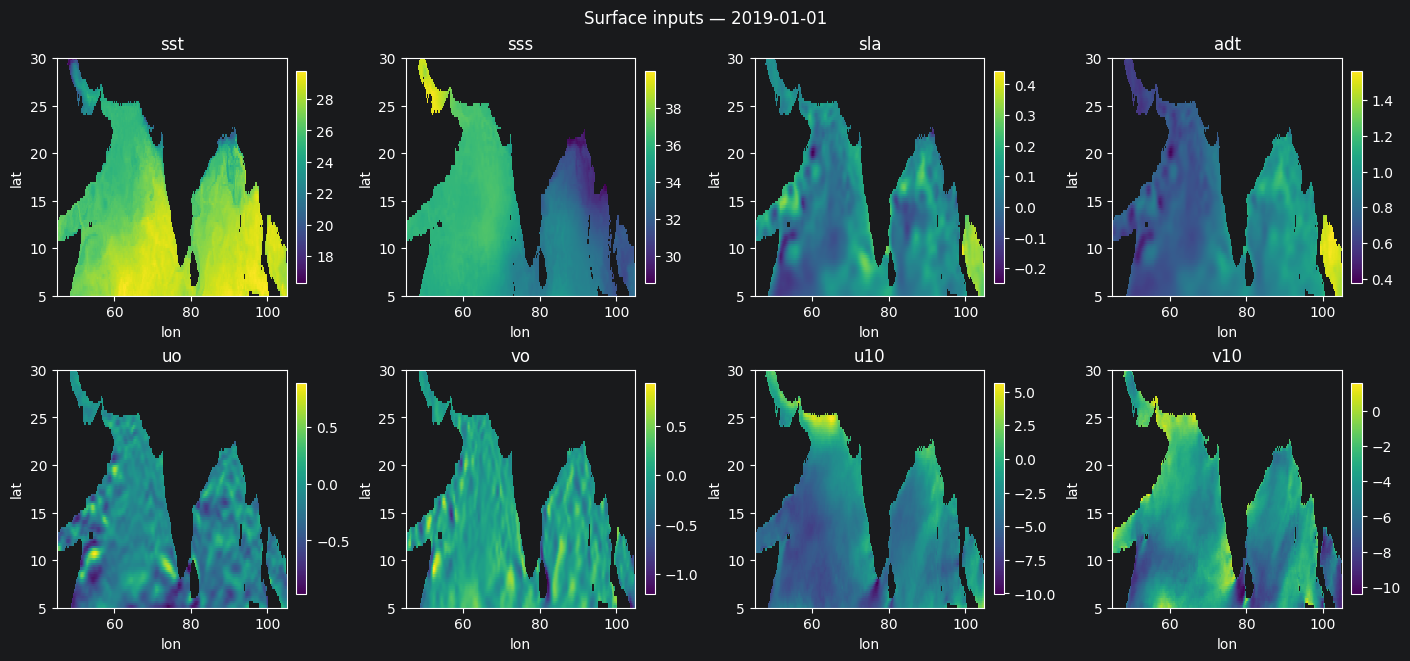

In [8]:
day_label = str(surface.time.values[DAY])[:10]
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), constrained_layout=True)

for ax, name in zip(axes.ravel(), CHANNELS):
    da = surface[name].isel(time=DAY)
    im = ax.pcolormesh(
        surface.longitude,
        surface.latitude,
        da,
        shading="auto",
        cmap="viridis",
    )
    ax.set_title(name)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"Surface inputs — {day_label}")
fig.savefig(OUT / "02_surface_channels.png", dpi=140)
plt.show()

## 4. Target temperature at selected depths

Same day, several depth slices of `thetao`.

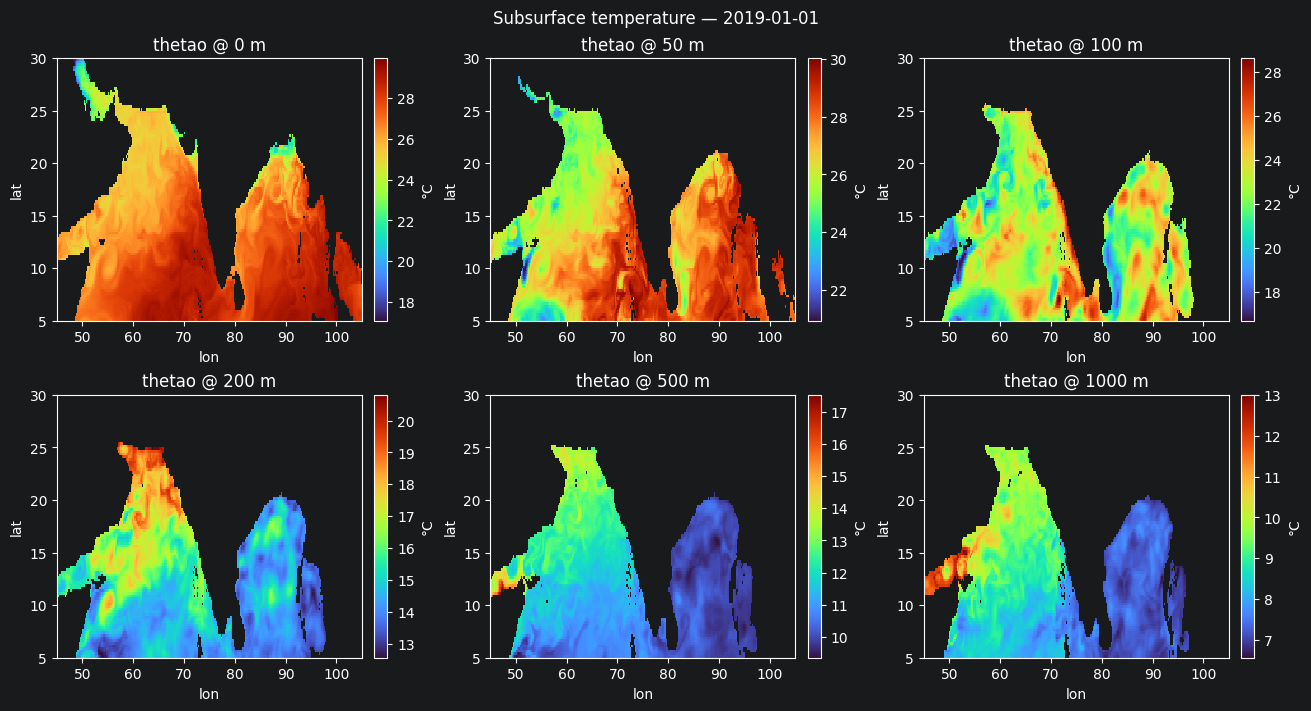

In [9]:
plot_depths = [0.0, 50.0, 100.0, 200.0, 500.0, 1000.0]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)

for ax, d in zip(axes.ravel(), plot_depths):
    da = target.thetao.isel(time=DAY).sel(depth=d)
    im = ax.pcolormesh(
        target.longitude,
        target.latitude,
        da,
        shading="auto",
        cmap="turbo",
    )
    ax.set_title(f"thetao @ {d:.0f} m")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="°C")

fig.suptitle(f"Subsurface temperature — {day_label}")
fig.savefig(OUT / "03_thetao_depths.png", dpi=140)
plt.show()

## 5. SST vs near-surface `thetao` (sanity / learnability)

Surface SST should track `thetao` at 0 m closely. Correlation should fall with depth.

corr(SST, thetao@     0 m) = 0.9811   n=1053630
corr(SST, thetao@     5 m) = 0.9772   n=1053630
corr(SST, thetao@    10 m) = 0.9743   n=1023480
corr(SST, thetao@    20 m) = 0.9637   n=995580
corr(SST, thetao@    30 m) = 0.9405   n=966420
corr(SST, thetao@    50 m) = 0.8346   n=925830
corr(SST, thetao@    75 m) = 0.4611   n=887760
corr(SST, thetao@   100 m) = 0.0836   n=867600
corr(SST, thetao@   125 m) = -0.2181   n=862650
corr(SST, thetao@   150 m) = -0.4237   n=858960
corr(SST, thetao@   200 m) = -0.6091   n=850500
corr(SST, thetao@   300 m) = -0.6483   n=843840
corr(SST, thetao@   500 m) = -0.6221   n=829620
corr(SST, thetao@   700 m) = -0.6020   n=816390
corr(SST, thetao@  1000 m) = -0.5837   n=808560


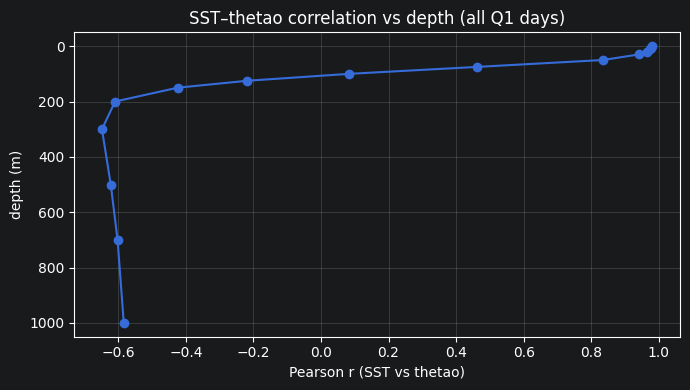

In [10]:
sst = surface.sst.values
corrs = []
for d in target.depth.values:
    layer = target.thetao.sel(depth=d).values
    m = np.isfinite(sst) & np.isfinite(layer)
    r = float(np.corrcoef(sst[m], layer[m])[0, 1]) if m.sum() > 100 else np.nan
    corrs.append(r)
    print(f"corr(SST, thetao@{float(d):6.0f} m) = {r:.4f}   n={m.sum()}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(corrs, target.depth.values, marker="o")
ax.invert_yaxis()
ax.set_xlabel("Pearson r (SST vs thetao)")
ax.set_ylabel("depth (m)")
ax.set_title("SST–thetao correlation vs depth (all Q1 days)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "04_sst_thetao_corr_vs_depth.png", dpi=140)
plt.show()

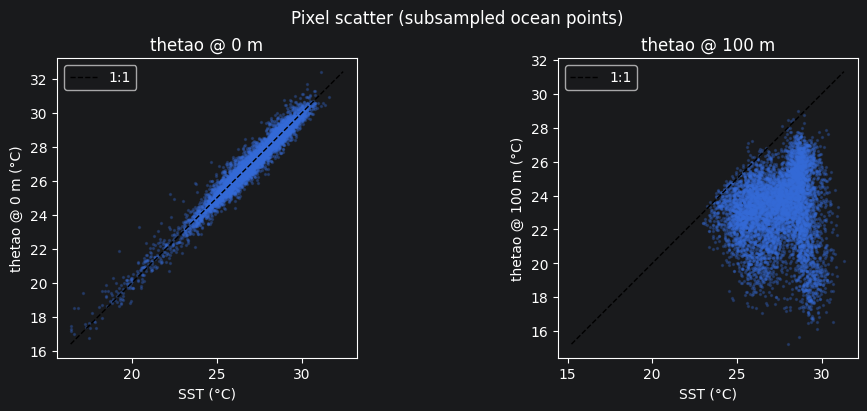

In [11]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, d, title in zip(axes, [0.0, 100.0], ["thetao @ 0 m", "thetao @ 100 m"]):
    layer = target.thetao.sel(depth=d).values
    m = np.isfinite(sst) & np.isfinite(layer)
    idx = rng.choice(m.sum(), size=min(8000, int(m.sum())), replace=False)
    xs = sst[m][idx]
    ys = layer[m][idx]
    ax.scatter(xs, ys, s=2, alpha=0.25)
    lims = [min(xs.min(), ys.min()), max(xs.max(), ys.max())]
    ax.plot(lims, lims, "k--", lw=1, label="1:1")
    ax.set_xlabel("SST (°C)")
    ax.set_ylabel(f"{title} (°C)")
    ax.set_title(title)
    ax.legend(loc="upper left")
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Pixel scatter (subsampled ocean points)")
fig.savefig(OUT / "05_sst_vs_thetao_scatter.png", dpi=140)
plt.show()

## 6. Vertical profiles at example locations

Each profile is what the model should predict under one ocean pixel from that day's surface fields.

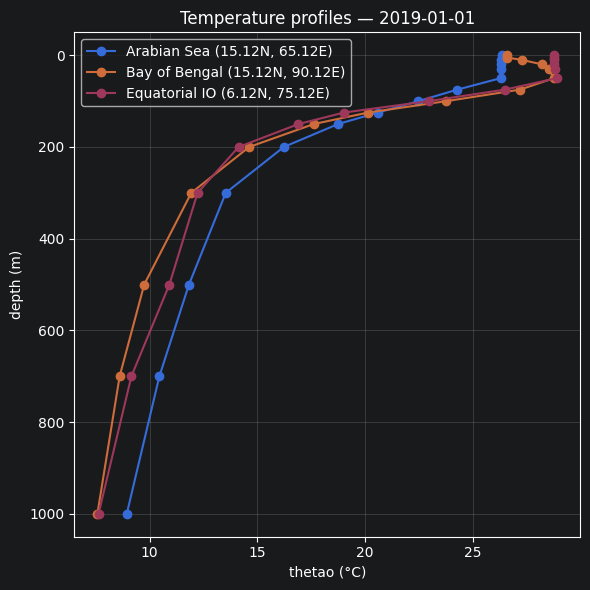

In [12]:
points = [
    ("Arabian Sea", 15.0, 65.0),
    ("Bay of Bengal", 15.0, 90.0),
    ("Equatorial IO", 6.0, 75.0),
]

fig, ax = plt.subplots(figsize=(6, 6))
for label, lat, lon in points:
    prof = target.thetao.isel(time=DAY).sel(latitude=lat, longitude=lon, method="nearest")
    if not np.isfinite(prof).any():
        print(f"skip {label}: no data")
        continue
    ax.plot(
        prof.values,
        target.depth.values,
        marker="o",
        label=f"{label} ({float(prof.latitude):.2f}N, {float(prof.longitude):.2f}E)",
    )

ax.invert_yaxis()
ax.set_xlabel("thetao (°C)")
ax.set_ylabel("depth (m)")
ax.set_title(f"Temperature profiles — {day_label}")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "06_profiles.png", dpi=140)
plt.show()

## 7. Takeaways for training

- **Sample shape:** one day → `X (8, H, W)`, `Y (15, H, W)` with shared lat/lon.
- **Mask:** use pixels where all needed surface channels **and** `thetao` are finite (land + shelf drop out at depth).
- **Signal:** SST ≈ `thetao@0m` (r ≈ 0.98); still useful to ~50–75 m; by ~100 m r collapses and goes **negative** at depth — SST alone cannot map deep structure; use the other 7 channels + spatial context (CNN).
- **Split:** hold out days by **time** (e.g. last ~2 weeks of Q1) — do not shuffle pixels across days for validation.

Figures saved under `outputs/eda/`. Run all cells top-to-bottom in Jupyter to refresh in-notebook plots.